In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
file_name = "acc102 data.xlsx"  
output_folder = "outputs"
os.makedirs(output_folder, exist_ok=True)

selected_stocks = ["MSFT", "NVDA", "AMD", "TSM", "PLTR", "ADBE", "CRM"]

start_date = "2021-01-01"
end_date = "2025-12-31"

In [2]:
df = pd.read_excel(file_name)
df.columns = df.columns.str.strip()

print("=== Columns ===")
print(df.columns.tolist())

print("\n=== First 5 rows ===")
print(df.head())

=== Columns ===
['PERMNO', 'Header CUSIP -8 Characters', 'CUSIP', 'Ticker', 'PERMCO', 'Issuer Name', 'Monthly Calendar Date', 'Monthly Price', 'Monthly Total Return', 'Monthly Volume', 'Shares Outstanding']

=== First 5 rows ===
   PERMNO Header CUSIP -8 Characters     CUSIP Ticker  PERMCO     Issuer Name  \
0   10107                   59491810  59491810   MSFT    8048  MICROSOFT CORP   
1   10107                   59491810  59491810   MSFT    8048  MICROSOFT CORP   
2   10107                   59491810  59491810   MSFT    8048  MICROSOFT CORP   
3   10107                   59491810  59491810   MSFT    8048  MICROSOFT CORP   
4   10107                   59491810  59491810   MSFT    8048  MICROSOFT CORP   

  Monthly Calendar Date  Monthly Price  Monthly Total Return  Monthly Volume  \
0            2020-01-31         170.23              0.079455       558834578   
1            2020-02-28         162.01             -0.045696       886595863   
2            2020-03-31         157.71      

In [3]:
df["Monthly Calendar Date"] = pd.to_datetime(df["Monthly Calendar Date"], errors="coerce")
df["Monthly Price"] = pd.to_numeric(df["Monthly Price"], errors="coerce")
df["Monthly Total Return"] = pd.to_numeric(df["Monthly Total Return"], errors="coerce")
df["Monthly Volume"] = pd.to_numeric(df["Monthly Volume"], errors="coerce")
print(df[["Ticker", "Monthly Calendar Date", "Monthly Price", "Monthly Total Return"]].head())

  Ticker Monthly Calendar Date  Monthly Price  Monthly Total Return
0   MSFT            2020-01-31         170.23              0.079455
1   MSFT            2020-02-28         162.01             -0.045696
2   MSFT            2020-03-31         157.71             -0.026542
3   MSFT            2020-04-30         179.21              0.136326
4   MSFT            2020-05-29         183.25              0.025352


In [4]:
df = df[df["Ticker"].isin(selected_stocks)].copy()
df = df.drop_duplicates(subset=["Ticker", "Monthly Calendar Date"])
df = df[
    (df["Monthly Calendar Date"] >= start_date) &
    (df["Monthly Calendar Date"] <= end_date)
].copy()
df = df.dropna(subset=["Monthly Price", "Monthly Total Return"])
df = df.sort_values(["Ticker", "Monthly Calendar Date"]).copy()
print("=== Number of observations by ticker ===")
print(df.groupby("Ticker").size())


=== Number of observations by ticker ===
Ticker
ADBE    60
AMD     60
CRM     60
MSFT    60
NVDA    60
PLTR    60
TSM     60
dtype: int64


In [5]:
df["Standardized Price"] = df.groupby("Ticker")["Monthly Price"].transform(
    lambda x: x / x.iloc[0] * 100
)
df["Cumulative Return Path"] = df.groupby("Ticker")["Monthly Total Return"].transform(
    lambda x: (1 + x).cumprod()
)
df["Year"] = df["Monthly Calendar Date"].dt.year
print(df[["Ticker", "Monthly Calendar Date", "Standardized Price", "Cumulative Return Path"]].head())

    Ticker Monthly Calendar Date  Standardized Price  Cumulative Return Path
425   ADBE            2021-01-29          100.000000                0.917320
426   ADBE            2021-02-26          100.196177                0.919119
427   ADBE            2021-03-31          103.618371                0.950512
428   ADBE            2021-04-30          110.804979                1.016436
429   ADBE            2021-05-28          109.985396                1.008918


In [6]:
summary_rows = []
for ticker, group in df.groupby("Ticker"):
    returns = group["Monthly Total Return"].dropna()
    n = len(returns)

    cumulative_return = (1 + returns).prod() - 1
    annualized_return = (np.prod(1 + returns) ** (12 / n)) - 1
    annualized_volatility = returns.std(ddof=1) * np.sqrt(12)

    summary_rows.append({
        "Ticker": ticker,
        "Months": n,
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility
    })
summary = pd.DataFrame(summary_rows)
summary["Cumulative Return (%)"] = summary["Cumulative Return"] * 100
summary["Annualized Return (%)"] = summary["Annualized Return"] * 100
summary["Annualized Volatility (%)"] = summary["Annualized Volatility"] * 100
summary = summary.sort_values(by="Annualized Return (%)", ascending=False).reset_index(drop=True)
print(summary[[
    "Ticker",
    "Months",
    "Cumulative Return (%)",
    "Annualized Return (%)",
    "Annualized Volatility (%)"
]])
summary.to_csv(os.path.join(output_folder, "summary_table.csv"), index=False)

  Ticker  Months  Cumulative Return (%)  Annualized Return (%)  \
0   NVDA      60            1332.522863              70.302221   
1   PLTR      60             654.777070              49.817912   
2    TSM      60             203.040513              24.824587   
3    AMD      60             133.518700              18.485262   
4   MSFT      60             126.619670              17.776738   
5    CRM      60              20.508668               3.801507   
6   ADBE      60             -30.018795              -6.890009   

   Annualized Volatility (%)  
0                  50.758980  
1                  77.249579  
2                  34.602890  
3                  56.923644  
4                  22.321296  
5                  34.002502  
6                  35.442855  


In [7]:
yearly_returns = df.groupby(["Ticker", "Year"])["Monthly Total Return"].apply(
    lambda x: (1 + x).prod() - 1
).reset_index()
yearly_pivot = yearly_returns.pivot(index="Year", columns="Ticker", values="Monthly Total Return")
print(yearly_pivot)
yearly_pivot.to_csv(os.path.join(output_folder, "yearly_returns.csv"))

Ticker      ADBE       AMD       CRM      MSFT      NVDA      PLTR       TSM
Year                                                                        
2021    0.133848  0.569076  0.142003  0.524761  1.254782 -0.226752  0.121038
2022   -0.406535 -0.549896 -0.478259 -0.280166 -0.502660 -0.647446 -0.367293
2023    0.772799  1.275899  0.984614  0.581919  2.390192  1.674455  0.422959
2024   -0.254643 -0.180585  0.277757  0.129204  1.712489  3.404776  0.925793
2025   -0.212940  0.772994 -0.202425  0.155863  0.389157  1.350258  0.559106


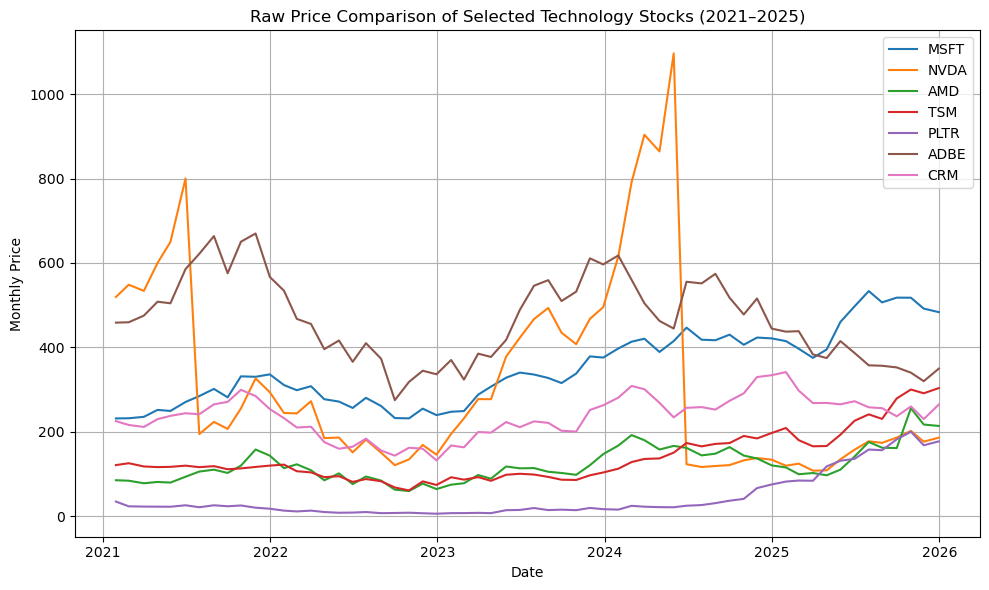

In [8]:
plt.figure(figsize=(10, 6))

for ticker in selected_stocks:
    stock_data = df[df["Ticker"] == ticker]
    plt.plot(
        stock_data["Monthly Calendar Date"],
        stock_data["Monthly Price"],
        label=ticker
    )

plt.xlabel("Date")
plt.ylabel("Monthly Price")
plt.title("Raw Price Comparison of Selected Technology Stocks (2021–2025)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "raw_price_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

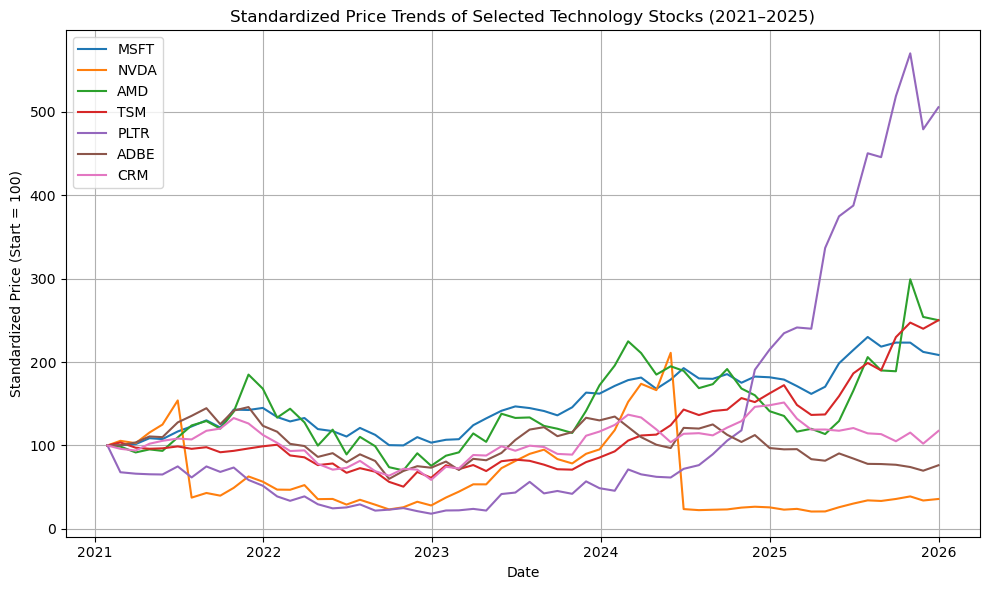

In [9]:
plt.figure(figsize=(10, 6))

for ticker in selected_stocks:
    stock_data = df[df["Ticker"] == ticker]
    plt.plot(
        stock_data["Monthly Calendar Date"],
        stock_data["Standardized Price"],
        label=ticker
    )

plt.xlabel("Date")
plt.ylabel("Standardized Price (Start = 100)")
plt.title("Standardized Price Trends of Selected Technology Stocks (2021–2025)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "standardized_price_trends.png"), dpi=300, bbox_inches="tight")
plt.show()

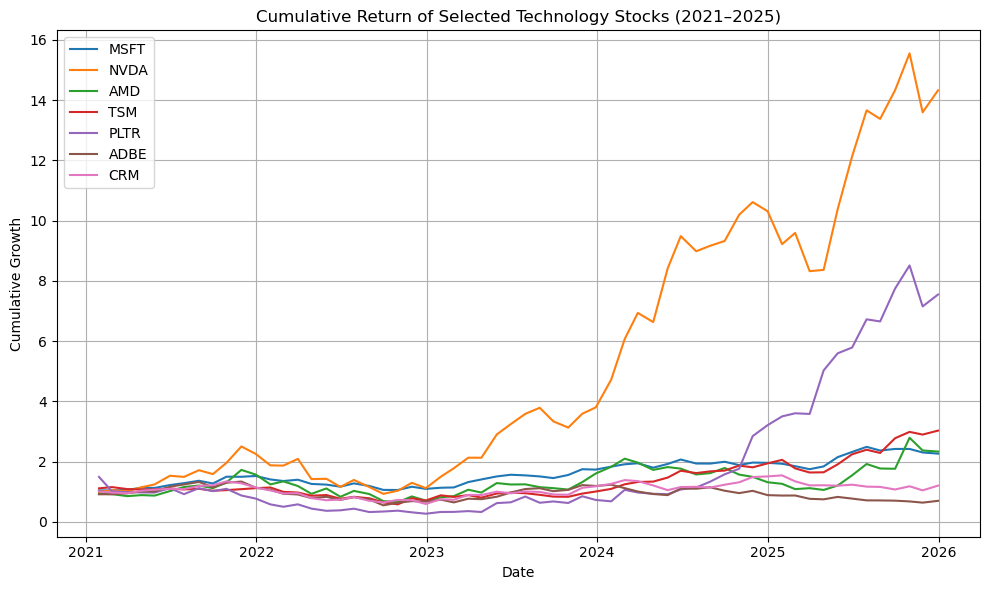

In [10]:
plt.figure(figsize=(10, 6))

for ticker in selected_stocks:
    stock_data = df[df["Ticker"] == ticker]
    plt.plot(
        stock_data["Monthly Calendar Date"],
        stock_data["Cumulative Return Path"],
        label=ticker
    )

plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.title("Cumulative Return of Selected Technology Stocks (2021–2025)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "cumulative_return_chart.png"), dpi=300, bbox_inches="tight")
plt.show()

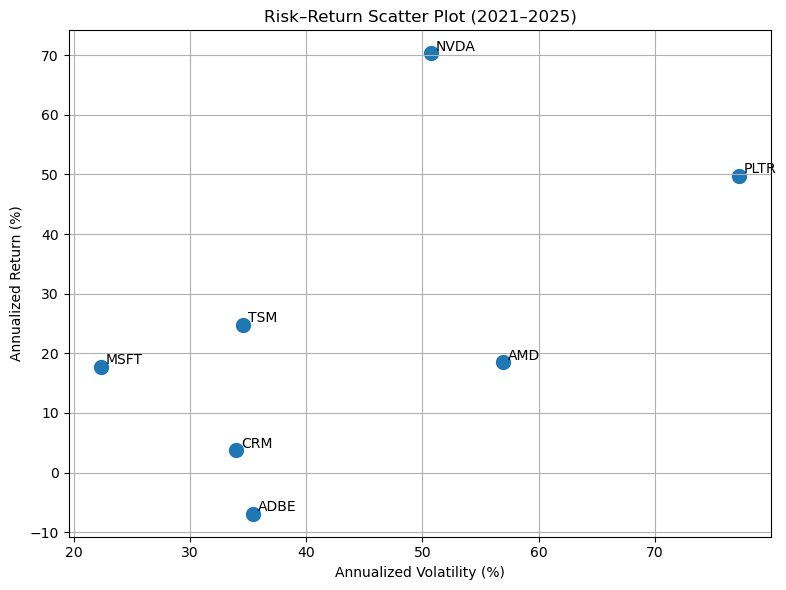

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    summary["Annualized Volatility (%)"],
    summary["Annualized Return (%)"],
    s=100
)

for i in range(len(summary)):
    plt.text(
        summary["Annualized Volatility (%)"].iloc[i] + 0.4,
        summary["Annualized Return (%)"].iloc[i] + 0.4,
        summary["Ticker"].iloc[i]
    )

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title("Risk–Return Scatter Plot (2021–2025)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "risk_return_scatter_plot.png"), dpi=300, bbox_inches="tight")
plt.show()

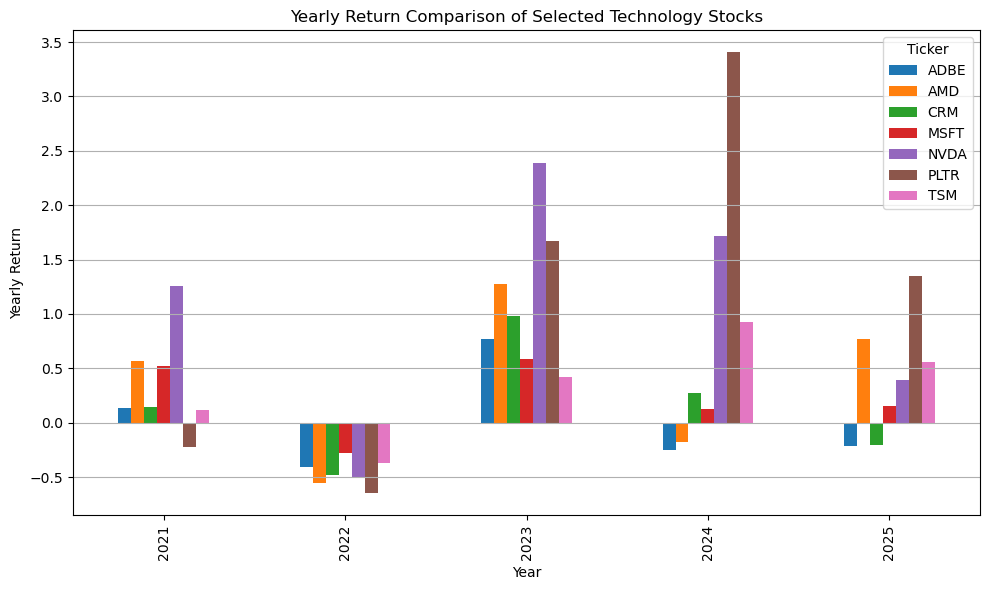

In [12]:
yearly_pivot.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Year")
plt.ylabel("Yearly Return")
plt.title("Yearly Return Comparison of Selected Technology Stocks")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "yearly_return_bar_chart.png"), dpi=300, bbox_inches="tight")
plt.show()

In [13]:
print("All outputs have been saved in the 'outputs' folder.")

All outputs have been saved in the 'outputs' folder.
